In [15]:
import pandas as pd

train_dataset = pd.read_csv("train_dataset.csv")
train_dataset

,key,SMILES,Alkaloids,Amino acids and Peptides,Carbohydrates,Fatty acids,Polyketides,Shikimates and Phenylpropanoids,Terpenoids,Alkylresorsinols,...,Vitamin D3 and derivatives,Wax diesters,Wax monoesters,Xeniaphyllane diterpenoids,Xenicane diterpenoids,Yohimbine-like alkaloids,Zearalenones,Zizaane sesquiterpenoids,m-Terphenyls,p-Terphenyls
0,HDSCVJJILDESMF,CCCCCCCCCCCCCCCC/C=C\OC[C@H](COP(=O)(OC)OC[C@@...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AFMYEZXBBZKRNP,CCCCCCCCCCCCCCCC/C=C\OC[C@H](COP(=O)(O)OC[C@H]...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,TVVFBXNPAMSMTB,CCCCCCCCCCCCCCCC/C=C\OC[C@H](COP(=O)(O)OC[C@@H...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,BSDAOJREDHDCJH,CCCCCCCCCCCCCCCC/C=C\OC[C@H](COP(=O)(O)OC[C@@H...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,KLADGQYNEYECIT,CCC(O)C1CCCC2C3C(=CCCN12)OC(=C1OC(=O)C(C)=C1OC...,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152382,MAPXUNQSUZDJSL,CC1=COC2C1(O)C(=O)C=C1C(=O)CCC(C)C12C,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
152383,PITGIIBORWZGAM,CC1=C2C(=O)OCC(C(=O)OC3C(CO)OC(O)C(O)C3OC(=O)C...,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
152384,SSBPHQDXIDTEDU,COc1cc(C[C@@H]2c3cc(OC)c(OC)cc3CCN2C)ccc1O,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
152385,MOHQPHOGSYSNPJ,COc1cc2c(cc1O)CCN(C)[C@@H]2Cc1ccc(OC)c(OC)c1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
test_dataset = pd.read_csv("test_dataset.csv")
set(test_dataset.key).intersection(set(train_dataset.key))

set()

In [19]:
len(set(test_dataset.key))

15541

In [2]:
from sklearn.metrics import f1_score

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

In [1]:
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

train_dataset = SingleInputDataset.from_csv("train_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                    labels_field=slice(2,-1))

In [2]:
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

validation_dataset = SingleInputDataset.from_csv("validation_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                    labels_field=slice(2,-1))

test_dataset = SingleInputDataset.from_csv("test_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                    labels_field=slice(2,-1))

In [3]:
from plants_sm.featurization.compounds.deepmol_descriptors import DeepMolDescriptors

featurizer = DeepMolDescriptors(preset="np_classifier_fp", n_jobs=10)
featurizer.fit_transform(train_dataset)

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-08-20 14:51:27.283909: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-20 14:51:27.287590: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-20 14:51:27.326185: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-20 14:51:27.326211: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609

In [4]:
featurizer.transform(validation_dataset)
featurizer.transform(test_dataset)

DeepMolDescriptors: 100%|██████████| 15541/15541 [00:04<00:00, 3678.80it/s]


In [5]:
train_dataset.save_features("train_dataset_np_fp")
validation_dataset.save_features("validation_dataset_np_fp")
test_dataset.save_features("test_dataset_np_fp")

In [6]:
from plants_sm.featurization.compounds.chembert2a import ChemBert2a

transformer = ChemBert2a()
transformer.fit_transform(train_dataset)
transformer.transform(validation_dataset)
transformer.transform(test_dataset)

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at DeepChem/ChemBERTa-77M-MTR were not used when initializing RobertaForMaskedLM: ['norm_mean', 'regression.out_proj.bias', 'regression.dense.weight', 'norm_std', 'regression.dense.bias', 'regression.out_proj.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a Ber

In [1]:
import warnings
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore", category=UserWarning)

from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

train_dataset = SingleInputDataset.from_csv("train_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                    labels_field=slice(2,-1))

train_dataset.load_features("train_dataset_np_fp")

from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

validation_dataset = SingleInputDataset.from_csv("validation_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                 labels_field=slice(2,-1))

validation_dataset.load_features("validation_dataset_np_fp")

from enzyme_substrate_prediction.models.np_classifier import NPClassifier
from plants_sm.models.lightning_model import InternalLightningModel
from lightning.pytorch.callbacks import EarlyStopping
from sklearn.metrics import average_precision_score

callbacks = EarlyStopping("val_loss", patience=5, mode="min")

module = NPClassifier(metric=None, original=True)
model = InternalLightningModel(module=module, max_epochs=100,
        batch_size=128,
        devices=[0],
        accelerator="gpu",
        callbacks=[callbacks]
        )
model.fit(train_dataset, validation_dataset)
model.save("np_classifier_original")

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
2024-08-20 17:35:44.941865: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENA

Epoch 24: 100%|██████████| 1191/1191 [00:25<00:00, 47.57it/s, v_num=31, train_loss_step=5.1e-5, val_loss=0.000901, train_loss_epoch=4.86e-5]   


In [1]:
from plants_sm.models.lightning_model import InternalLightningModel
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from enzyme_substrate_prediction.models.np_classifier import NPClassifier

train_dataset = SingleInputDataset.from_csv("train_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                    labels_field=slice(2,-1))

train_dataset.load_features("train_dataset_np_fp")

from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

validation_dataset = SingleInputDataset.from_csv("validation_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                 labels_field=slice(2,-1))

validation_dataset.load_features("validation_dataset_np_fp")

test_dataset = SingleInputDataset.from_csv("test_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                    labels_field=slice(2,-1))

test_dataset.load_features("test_dataset_np_fp")


model = InternalLightningModel.load("np_classifier_original")


/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimenta

In [2]:
import pickle
import numpy as np
from tqdm import tqdm
from rdkit import Chem
from sklearn.model_selection import train_test_split
import os
from joblib import Parallel, delayed
from sklearn.metrics import f1_score, average_precision_score


np.random.seed(0)


with open('./data/char2idx_class_V1.pkl','rb') as f:
    class_  = pickle.load(f)
with open('./data/char2idx_super_V1.pkl','rb') as f:
    superclass_  = pickle.load(f)
with open('./data/char2idx_path_V1.pkl','rb') as f:
    pathway_  = pickle.load(f)

pathway_names = list(pathway_.keys())
pathway_indexes = [i for i, label in enumerate(test_dataset._labels_names) if label in pathway_names]

superclass_names = list(superclass_.keys())
superclass_indexes = [i for i, label in enumerate(test_dataset._labels_names) if label in superclass_names]

class_names = list(class_.keys())
class_indexes = [i for i, label in enumerate(test_dataset._labels_names) if label in class_names]

def average_precision_score_macro(y_true, y_pred):
    return average_precision_score(y_true, y_pred, average="macro")

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


In [3]:

validation_proba = model.predict_proba(validation_dataset)
validation_pred = model.predict(validation_dataset)
print(f1_macro(validation_dataset.y, validation_pred))
print(f1_macro(validation_dataset.y[:, pathway_indexes], validation_pred[:, pathway_indexes]))
print(f1_macro(validation_dataset.y[:, superclass_indexes], validation_pred[:, superclass_indexes]))
print(f1_macro(validation_dataset.y[:, class_indexes], validation_pred[:, class_indexes]))
print(average_precision_score_macro(validation_dataset.y[:, pathway_indexes], validation_proba[:, pathway_indexes]))
print(average_precision_score_macro(validation_dataset.y[:, superclass_indexes], validation_proba[:, superclass_indexes]))
print(average_precision_score_macro(validation_dataset.y[:, class_indexes], validation_proba[:, class_indexes]))

Missing logger folder: /home/jcapela/enzyme-substrate-interaction/pipeline_rhea/train_compounds_NP_prediction/lightning_logs
2025-03-20 14:24:03.316318: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-20 14:24:03.319920: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 14:24:03.355660: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-20 14:24:03.355686: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-20 14:24:03.35

Predicting DataLoader 0: 100%|██████████| 389/389 [00:04<00:00, 93.27it/s]


/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))


0.8981190131375112
0.9864237785608424
0.9576761935770417


/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))


0.890788023874524
0.9946140744401433
0.9794832085962408


/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warni

0.9351002327907374


In [5]:
test_proba = model.predict_proba(test_dataset)
test_pred = model.predict(test_dataset)
print(f1_macro(test_dataset.y[:, pathway_indexes], test_pred[:, pathway_indexes]))
print(f1_macro(test_dataset.y[:, superclass_indexes], test_pred[:, superclass_indexes]))
print(f1_macro(test_dataset.y[:, class_indexes], test_pred[:, class_indexes]))
print(average_precision_score_macro(test_dataset.y[:, pathway_indexes], test_proba[:, pathway_indexes]))
print(average_precision_score_macro(test_dataset.y[:, superclass_indexes], test_proba[:, superclass_indexes]))
print(average_precision_score_macro(test_dataset.y[:, class_indexes], test_proba[:, class_indexes]))

Predicting DataLoader 0: 100%|██████████| 486/486 [00:06<00:00, 72.90it/s]
0.9857821284560384
0.9522309888253858
0.9040624240099858
0.9942814168430493
0.9734104562185627
0.9501170930034427


In [13]:
test_dataset.y.shape

(15541, 730)

In [14]:
validation_dataset.y.shape

(12433, 730)

In [12]:
print(f1_macro(test_dataset.y, test_pred))
print(average_precision_score_macro(test_dataset.y, test_proba))

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))


0.913617254871039


/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warni

0.9552771621583642


torch.Size([12433, 730])

In [4]:
pathway_names = list(pathway_.keys())
pathway_indexes = [i for i, label in enumerate(test_dataset._labels_names) if label in pathway_names]

# get the ones in the matrix test_dataset.y[:, pathway_indexes] and attribute a pathway to them
def get_pathway(y):
    indexes = np.where(y == 1)[0]
    pathway = pathway_names[indexes[0]]
    return pathway

pathways = [get_pathway(y) for y in test_dataset.y[:, pathway_indexes]]

In [5]:
# generate a umap embedding from the embedding
import umap


mapper = umap.UMAP().fit(embedding)

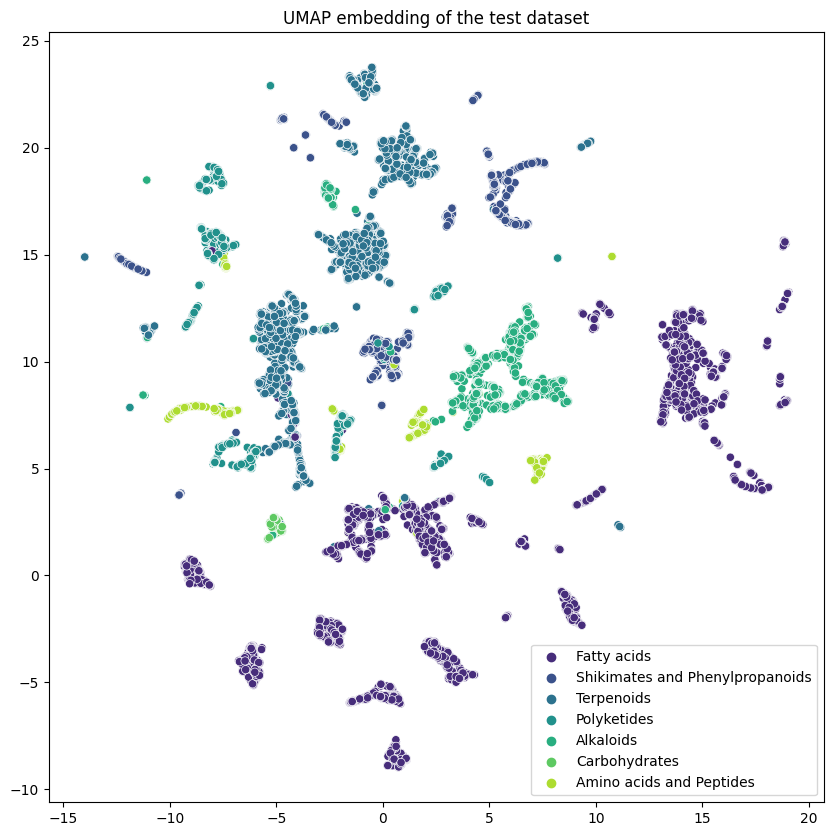

In [9]:
umap_embedding = mapper.transform(embedding)

# plot the umap embedding with the pathways descriminated by color
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.scatterplot(x=umap_embedding[:, 0], y=umap_embedding[:, 1], hue=pathways, palette="viridis")
plt.title("UMAP embedding of the test dataset")
plt.show()


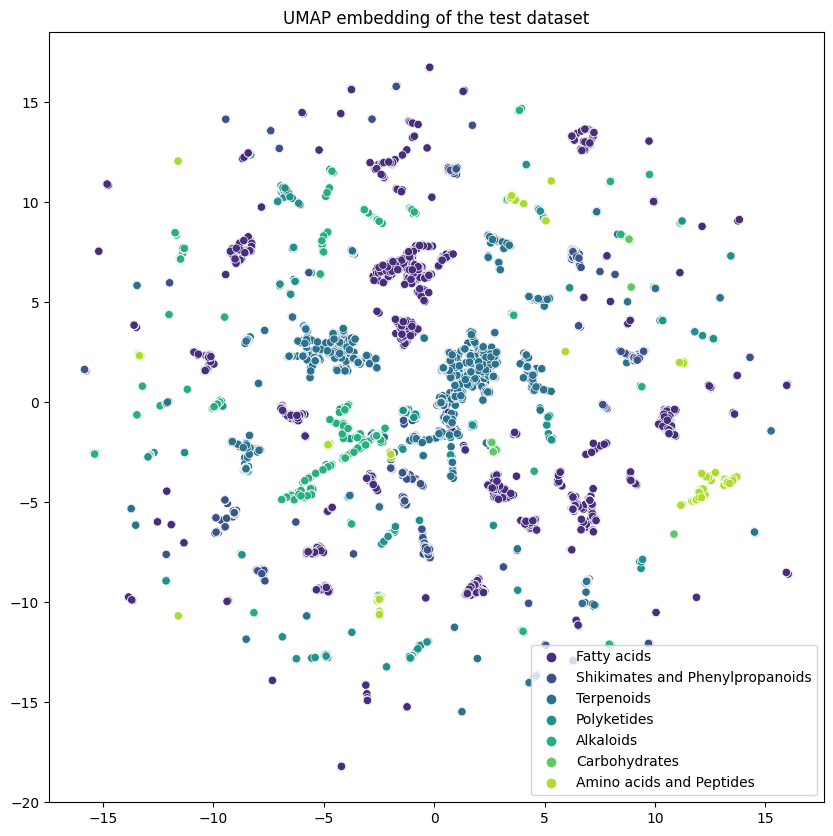

In [6]:
umap_embedding = mapper.transform(embedding)

# plot the umap embedding with the pathways descriminated by color
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.scatterplot(x=umap_embedding[:, 0], y=umap_embedding[:, 1], hue=pathways, palette="viridis")
plt.title("UMAP embedding of the test dataset")
plt.show()


In [9]:
test = model.predict(test_dataset)

Predicting DataLoader 0: 100%|██████████| 122/122 [00:03<00:00, 39.42it/s]


In [11]:
f1_macro(test_dataset.y, test)

0.9054335270815419

# Test with chemberta

In [3]:
from plants_sm.featurization.compounds.chembert2a import ChemBert2a

transformer = ChemBert2a()
transformer.fit(train_dataset)
transformer.transform(test_dataset)

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at DeepChem/ChemBERTa-77M-MTR were not used when initializing RobertaForMaskedLM: ['regression.out_proj.bias', 'regression.out_proj.weight', 'norm_std', 'regression.dense.bias', 'norm_mean', 'regression.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a Ber

In [8]:
train_dataset.save_features("train_dataset_features")
validation_dataset.save_features("validation_dataset_features")
test_dataset.save_features("test_dataset_features")

In [ ]:
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

train_dataset = SingleInputDataset.from_csv("train_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                    labels_field=slice(2,-1))

train_dataset.load_features("train_dataset_features")

from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

validation_dataset = SingleInputDataset.from_csv("validation_dataset.csv", representation_field="SMILES", instances_ids_field="key",
                                                    labels_field=slice(2,-1))

validation_dataset.load_features("validation_dataset_features")

from enzyme_substrate_prediction.models import ModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel
from lightning.pytorch.callbacks import EarlyStopping
from sklearn.metrics import average_precision_score

callbacks = EarlyStopping("val_metric", patience=5, mode="max")

module = ModelECNumber(input_dim=600, layers=[1200, 1200], classification_neurons=730, metric=average_precision_score)
model = InternalLightningModel(module=module, max_epochs=2,
        batch_size=16,
        devices=[2],
        accelerator="gpu",
        callbacks=[callbacks]
        )
model.fit(train_dataset, validation_dataset)
model.save("chembert2a_model")

In [ ]:
from plants_sm.models.lightning_model import InternalLightningModel
model = InternalLightningModel.load("chembert2a_model")

In [ ]:
test_dataset.load_features("test_dataset_features")

In [6]:
predictions = model.predict(test_dataset)
average_precision_score(test_dataset.y, predictions)

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 486/486 [01:35<00:00,  5.09it/s]


/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warni

0.004296955309097201